Recreating the hybrid Monte Carlo algorithm as in Chafai and Ferre.

In [ ]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

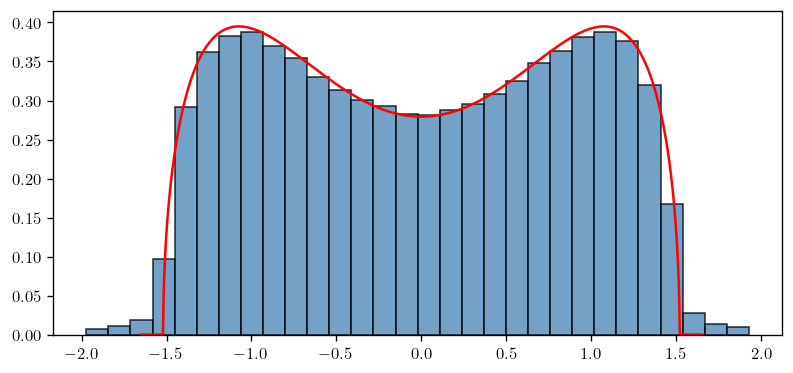

{'snapshots': array([-1.40129104, -1.37931639, -1.36069581, ...,  1.34091668,
         1.40059612,  1.50187541]),
 'accepts': array([0.98, 0.94, 0.84, ..., 0.94, 0.94, 0.94]),
 'cross_rejects': array([0.02, 0.04, 0.14, ..., 0.  , 0.  , 0.  ])}

In [15]:
N = 70; dt = N**(-3/2);
beta = 2.0; T = 10.0; M = 50; potential_name = "quartic"
total_steps = int(T/dt)

init = random_matrix.init_gue_eigenvalues(M, N)
hmc_pipe = simulate.make_hmc_pipeline(N, dt, potential_name, beta)
traj = simulate.simulate_dbm(init, total_steps, hmc_pipe)

config = {"track_accepts": True, "burn_in": int(3.0/dt)}
all_info = simulate.analyse_trajectory(traj, total_steps, **config)

fig, ax = plt.subplots()
plotters.plot_hist(ax, all_info["snapshots"], potential_name = potential_name, num_bins = 30)

plt.show()

all_info